In [1]:
# Data Manipulations
import pandas as pd
import numpy as np

# Handling Images
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# Pytorch Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models
from torchvision.datasets import ImageFolder
import torchsummary

# Data augmentation
import torchvision
from torchvision import datasets, transforms, utils
from torchvision.transforms import v2

import cv2
import os
from glob import glob
from tqdm import tqdm
import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , accuracy_score, classification_report

In [4]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: authenticradio
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


In [5]:
train_df = pd.DataFrame({
    "path":[],
    "label":[],
    "class_id":[]
})

train_path = '/content/bean-leaf-lesions-classification/train'
folder_list = os.listdir(train_path)
print(folder_list)

['bean_rust', 'angular_leaf_spot', 'healthy']


In [6]:
label_dict = {
    "healthy":0,
    "angular_leaf_spot":1,
    "bean_rust":2,
}

In [ ]:
for i, folder in enumerate(folder_list):
  img_path = os.path.join(train_path, folder)
  jpg_list = glob(img_path+'/*.jpg')
  for jpg in jpg_list:
    new_data =pd.DataFrame({"path":jpg,"label":folder, "class_id":label_dict[folder]}, index=[1])
    train_df = pd.concat([train_df, new_data], ignore_index=True)

In [8]:
train_df[["path"]] = train_df[["path"]].astype(str)
train_df[["label"]] = train_df[["label"]].astype(str)
train_df[["class_id"]] = train_df[["class_id"]].astype(int)

In [9]:
train_df.head()

,path,label,class_id
0,/content/bean-leaf-lesions-classification/trai...,bean_rust,2
1,/content/bean-leaf-lesions-classification/trai...,bean_rust,2
2,/content/bean-leaf-lesions-classification/trai...,bean_rust,2
3,/content/bean-leaf-lesions-classification/trai...,bean_rust,2
4,/content/bean-leaf-lesions-classification/trai...,bean_rust,2


In [10]:
val_df = pd.DataFrame({
    "path":[],
    "label":[],
    "class_id":[]
})
val_path = '/content/bean-leaf-lesions-classification/val'
folder_list = os.listdir(val_path)
print(folder_list)

['bean_rust', 'angular_leaf_spot', 'healthy']


In [11]:
for i, folder in enumerate(folder_list):
    img_path = os.path.join(val_path, folder)
    jpg_list = glob(img_path+'/*.jpg')
    for jpg in jpg_list:
        new_data =pd.DataFrame({"path":jpg,"label":folder, "class_id":label_dict[folder]}, index=[1])
        val_df = pd.concat([val_df, new_data], ignore_index=True)

val_df[["path"]] = val_df[["path"]].astype(str)
val_df[["label"]] = val_df[["label"]].astype(str)
val_df[["class_id"]] = val_df[["class_id"]].astype(int)

In [12]:
val_df.head()

,path,label,class_id
0,/content/bean-leaf-lesions-classification/val/...,bean_rust,2
1,/content/bean-leaf-lesions-classification/val/...,bean_rust,2
2,/content/bean-leaf-lesions-classification/val/...,bean_rust,2
3,/content/bean-leaf-lesions-classification/val/...,bean_rust,2
4,/content/bean-leaf-lesions-classification/val/...,bean_rust,2


In [13]:
train_df['label'].value_counts()

,count
label,
bean_rust,348
angular_leaf_spot,345
healthy,341


<ipython-input-14-404620bee52f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


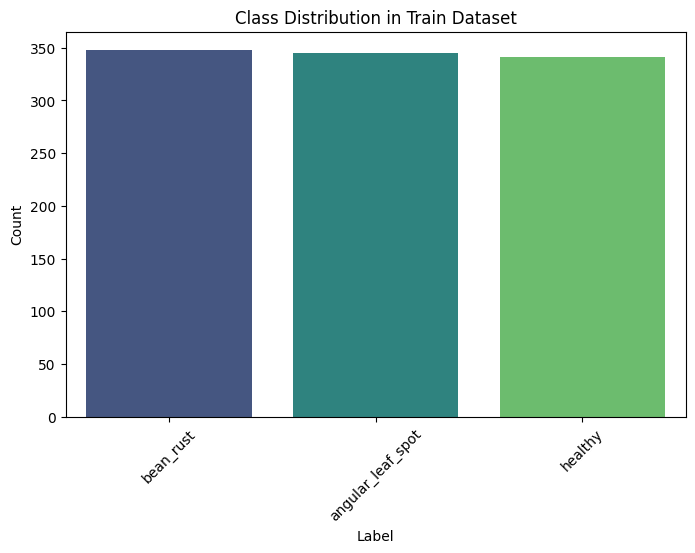

In [14]:
# Count occurrences of each label
label_counts = train_df['label'].value_counts()

# Plot the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")

# Labels and title
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Class Distribution in Train Dataset")
plt.xticks(rotation=45)

# Show plot
plt.show()

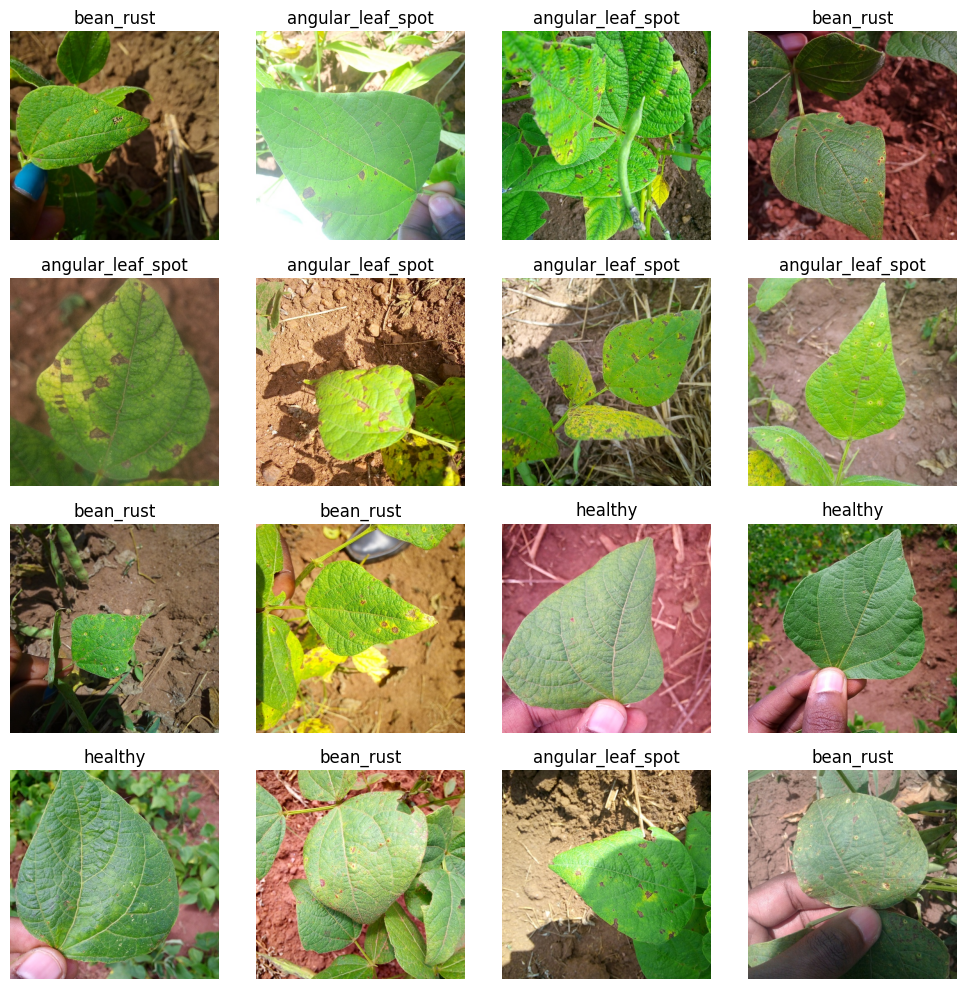

In [15]:
# Randomly select 16 images
sample_df = train_df.sample(n=16, random_state=42)  # Set random_state for reproducibility
image_paths = sample_df['path'].values
labels = sample_df['label'].values

# Create a 4x4 grid
plt.figure(figsize=(10, 10))

for i, (img_path, label) in enumerate(zip(image_paths, labels)):
    plt.subplot(4, 4, i + 1)
    img = Image.open(img_path)  # Open image
    plt.imshow(img)
    plt.axis("off")
    plt.title(label)

plt.tight_layout()
plt.show()

## Create Dataset and DataLoader


### **🔹 What Each Transformation Does**

| **Transformation**           | **Effect** | **Example** |
|------------------------------|-----------|------------|
| `v2.Resize(256)` | Resizes the shorter side of the image to 256 pixels, keeping aspect ratio. | If the original image is **500x400**, it resizes to **256x205**. |
| `v2.RandomResizedCrop(size=(224, 224))` | Randomly crops a **224×224** region from the resized image. | If the image is **256x205**, it randomly crops a **224x224** part. |
| `v2.RandomHorizontalFlip(p=0.5)` | Flips the image **horizontally** 50% of the time. | Image of **dog facing left** → **dog facing right** |
| `v2.RandomVerticalFlip(p=0.5)` | Flips the image **vertically** 50% of the time. | Image of **tree standing** → **tree upside-down** |
| `v2.RandomAffine(degrees=(-10, 10), translate=(0.1, 0.1), scale=(0.9, 1.1))` | Applies random **rotation**, **shifting**, and **scaling**. | Rotates up to ±10°, shifts 10%, scales ±10%. |
| `v2.RandomErasing(p=0.5, scale=(0.1, 0.15))` | Randomly erases a **small patch** in the image to prevent overfitting. | Removes **10% to 15%** of pixels randomly. |
| `v2.PILToTensor()` | Converts the image to a **PyTorch tensor** (C, H, W). | Converts from **(H, W, C) → (C, H, W)**. |
| `v2.ToDtype(torch.float32)` | Converts tensor data type to **float32**. | Helps with faster computations in PyTorch. |
| `v2.Normalize(mean, std)` | Normalizes pixel values to **zero mean, unit variance**. | Centers image pixels for better training. |

---

### **🔹 Example: Manual Walkthrough**
Assume we have an image **cat.jpg** (original size **500×400** pixels):

#### **Step-by-Step Transformation on `cat.jpg`**
| Step | Operation | Example Output |
|------|-----------|----------------|
| **1** | Resize(256) | Image → 256x205 |
| **2** | RandomResizedCrop(224,224) | Image → 224x224 (random part selected) |
| **3** | RandomHorizontalFlip(0.5) | 50% chance: image flips left-right |
| **4** | RandomAffine | 10° rotation, shift ±10%, scale 0.9-1.1 |
| **5** | RandomErasing(0.5) | 50% chance: erases a small patch |
| **6** | Convert to Tensor | Image → PyTorch tensor **(3, 224, 224)** |
| **7** | Normalize | Pixel values adjusted |

In [16]:
# Training data transformations
train_transforms = v2.Compose([
    v2.Resize(256),  # Resize the image to 256 pixels (preserving aspect ratio)
    v2.RandomResizedCrop(size=(224, 224), antialias=True),  # Randomly crop a 224x224 region
    v2.RandomHorizontalFlip(p=0.5),  # Flip the image horizontally with a 50% chance
    v2.RandomVerticalFlip(p=0.5),  # Flip the image vertically with a 50% chance
    v2.RandomAffine(degrees=(-10, 10),  # Rotate between -10° to 10°
                    translate=(0.1, 0.1),  # Shift up to 10% in x & y directions
                    scale=(0.9, 1.1)),  # Scale between 90% to 110%
    v2.RandomErasing(p=0.5, scale=(0.1, 0.15)),  # Erase a random patch of the image
    v2.PILToTensor(),  # Convert the image to a tensor (C, H, W)
    v2.ToDtype(torch.float32),  # Convert to float32 tensor
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

# Testing data transformations
test_transforms = v2.Compose([
    v2.Resize((224, 224)),  # Resize to 224x224 (no cropping)
    v2.PILToTensor(),  # Convert to tensor
    v2.ToDtype(torch.float32),  # Convert to float32 tensor
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])


In [17]:
train_df.iloc[0]['path']

'/content/bean-leaf-lesions-classification/train/bean_rust/bean_rust_train.41.jpg'

In [18]:
from torch.utils.data import DataLoader, Dataset

In [24]:
class MyDataset(Dataset):
    def __init__(self, dataframe, transforms_):
        self.df = dataframe
        self.transforms = transforms_  # Use transforms for augmentation & tensor conversion

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        image_path = self.df.iloc[index]['path']
        img = Image.open(image_path).convert('RGB')  # Open image & convert to RGB
        transformed_img = self.transforms(img)  # Apply transformations
        class_id = self.df.iloc[index]['class_id']
        return transformed_img, class_id

# Define datasets
train_dataset = MyDataset(train_df, train_transforms)
val_dataset = MyDataset(val_df, test_transforms)

# Define data loaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)


In [25]:
print(f'train data:{len(train_df)}')
print(f'val data:{len(val_df)}')

train data:1034
val data:133


## Create Model

In [26]:
class_size = 3
model = models.efficientnet_v2_s(weights='DEFAULT')

model.classifier[1] = torch.nn.Linear(1280, class_size)
model(torch.rand(16, 3, 256, 256)).shape

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:01<00:00, 82.5MB/s]


torch.Size([16, 3])

## Training and Validation

In [27]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")
num_workers = 2 if device=='cuda' else 4

In [28]:
def train(dataloader, model, loss_fn, optimizer, lr_scheduler):
    # Get dataset size and number of batches
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    # Set model to training mode
    model.train()
    epoch_loss = 0.0
    epoch_correct = 0

    # Loop through each batch of data
    for (data, target) in dataloader:
        # Convert target to correct type and move data to device
        target = target.type(torch.LongTensor)
        data, target = data.to(device), target.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass: get predictions
        outputs = model(data)

        # Calculate loss
        loss = loss_fn(outputs, target)

        # Backward pass: calculate gradients
        loss.backward()

        # Update model weights
        optimizer.step()

        # Track statistics
        epoch_loss += loss.item()
        _, pred = torch.max(outputs, dim=1)
        epoch_correct += torch.sum(pred == target).item()

    # Update learning rate
    lr_scheduler.step()

    # Return accuracy and average loss
    return epoch_correct/size, epoch_loss/num_batches


def test(dataloader, model, loss_fn):
    # Get dataset size and number of batches
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    epoch_loss = 0.0
    epoch_correct = 0

    # Disable gradient calculation for evaluation
    with torch.no_grad():
        # Set model to evaluation mode
        model.eval()

        # Loop through each batch of data
        for (data, target) in dataloader:
            # Convert target to correct type and move data to device
            target = target.type(torch.LongTensor)
            data, target = data.to(device), target.to(device)

            # Forward pass: get predictions
            outputs = model(data)

            # Calculate loss
            loss = loss_fn(outputs, target)

            # Track statistics
            epoch_loss += loss.item()
            _, pred = torch.max(outputs, dim=1)
            epoch_correct += torch.sum(pred == target).item()

    # Return accuracy and average loss
    return epoch_correct/size, epoch_loss/num_batches

In [29]:
# Move model to the right device (GPU or CPU)
model.to(device)

# Set number of training rounds
EPOCHS = 50

# Dictionary to track performance metrics
logs = {
    'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []
}

# Define loss function (measures prediction errors)
criterion = nn.CrossEntropyLoss()

# Configure optimizer settings
learning_rate = 0.0001
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Learning rate scheduler (reduces learning rate at specific epochs)
lr_milestones = [7, 14, 21, 28, 35]
multi_step_lr_scheduler = lr_scheduler.MultiStepLR(optimizer, milestones=lr_milestones, gamma=0.1)

# Early stopping setup (stops training if model stops improving)
patience = 5
counter = 0
best_loss = np.inf

# Training loop
for epoch in tqdm(range(EPOCHS)):
    # Train for one epoch and get metrics
    train_acc, train_loss = train(train_loader, model, criterion, optimizer, multi_step_lr_scheduler)

    # Evaluate on validation data
    val_acc, val_loss = test(val_loader, model, criterion)

    # Print progress
    print(f'EPOCH: {epoch} \
    train_loss: {train_loss:.4f}, train_acc: {train_acc:.3f} \
    val_loss: {val_loss:.4f}, val_acc: {val_acc:.3f} \
    Learning Rate: {optimizer.param_groups[0]["lr"]}')

    # Store metrics
    logs['train_loss'].append(train_loss)
    logs['train_acc'].append(train_acc)
    logs['val_loss'].append(val_loss)
    logs['val_acc'].append(val_acc)

    # Save current model state
    torch.save(model.state_dict(), "last.pth")

    # Early stopping check
    if val_loss < best_loss:
        counter = 0
        best_loss = val_loss
        torch.save(model.state_dict(), "best.pth")  # Save best model
    else:
        counter += 1

    # Stop training if no improvement for 'patience' epochs
    if counter >= patience:
        print("Earlystop!")
        break

  0%|          | 0/50 [00:00<?, ?it/s]

EPOCH: 0     train_loss: 0.7866, train_acc: 0.667     val_loss: 0.3117, val_acc: 0.872     Learning Rate: 0.0001


  2%|▏         | 1/50 [00:22<18:11, 22.28s/it]

EPOCH: 1     train_loss: 0.3260, train_acc: 0.869     val_loss: 0.0623, val_acc: 0.985     Learning Rate: 0.0001


  4%|▍         | 2/50 [00:42<16:49, 21.02s/it]

...

EPOCH: 13     train_loss: 0.0963, train_acc: 0.965     val_loss: 0.0341, val_acc: 0.985     Learning Rate: 1.0000000000000002e-06


 28%|██▊       | 14/50 [04:52<12:43, 21.20s/it]

EPOCH: 14     train_loss: 0.1076, train_acc: 0.962     val_loss: 0.0398, val_acc: 0.985     Learning Rate: 1.0000000000000002e-06


 28%|██▊       | 14/50 [05:14<13:28, 22.47s/it]

Earlystop!


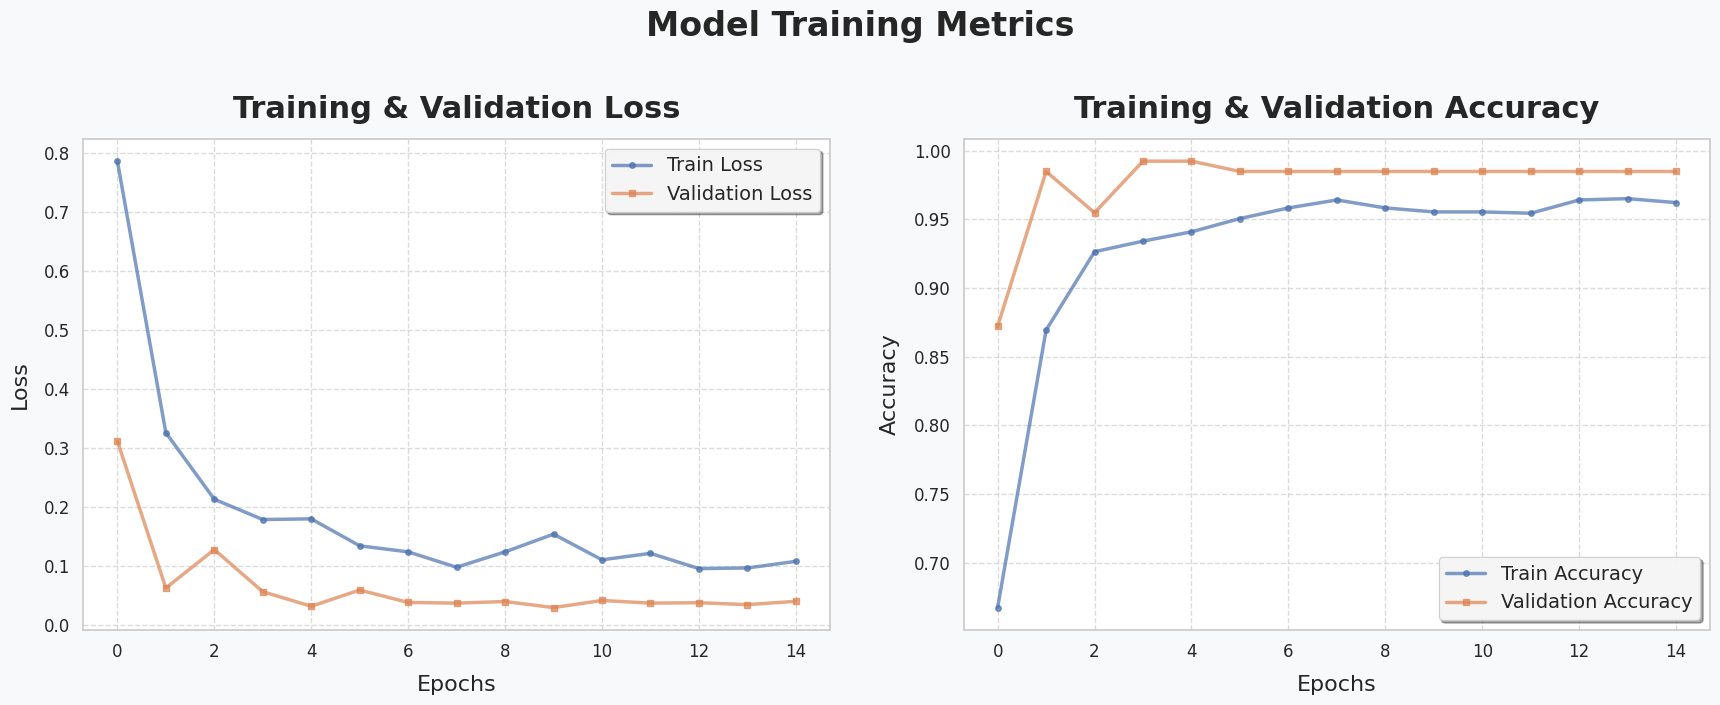

In [31]:
# Set the seaborn aesthetic parameters
sns.set(style="whitegrid")  # Use whitegrid style for better readability

# Use default system fonts instead of specifying Arial which may not be available
plt.rcParams['font.family'] = 'DejaVu Sans'  # This is usually available on most systems

# Create a figure with larger size and better resolution
plt.figure(figsize=(18, 7), dpi=100)

# First subplot - Loss
plt.subplot(1, 2, 1)
with sns.color_palette("viridis", 2):  # Using viridis color palette
    plt.plot(logs['train_loss'], linewidth=2.5, marker='o', markersize=4, alpha=0.7, label='Train Loss')
    plt.plot(logs['val_loss'], linewidth=2.5, marker='s', markersize=4, alpha=0.7, label='Validation Loss')

# Enhance the title and labels
plt.title('Training & Validation Loss', fontsize=22, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=16, labelpad=10)
plt.ylabel('Loss', fontsize=16, labelpad=10)
plt.legend(fontsize=14, frameon=True, facecolor='white', framealpha=0.9,
           shadow=True, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=12)

# Second subplot - Accuracy
plt.subplot(1, 2, 2)
with sns.color_palette("magma", 2):  # Using magma color palette for contrast
    plt.plot(logs['train_acc'], linewidth=2.5, marker='o', markersize=4, alpha=0.7, label='Train Accuracy')
    plt.plot(logs['val_acc'], linewidth=2.5, marker='s', markersize=4, alpha=0.7, label='Validation Accuracy')

# Enhance the title and labels
plt.title('Training & Validation Accuracy', fontsize=22, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=16, labelpad=10)
plt.ylabel('Accuracy', fontsize=16, labelpad=10)
plt.legend(fontsize=14, frameon=True, facecolor='white', framealpha=0.9,
           shadow=True, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=12)

# Add a subtle background color to the entire figure
fig = plt.gcf()
fig.patch.set_facecolor('#f8f9fa')

# Improve spacing between subplots
plt.tight_layout(pad=3.0)

# Optional: Add a suptitle for the entire figure
plt.suptitle('Model Training Metrics', fontsize=24, fontweight='bold', y=1.05)

# Show the plot
plt.show()

In [32]:
model.load_state_dict(torch.load('best.pth'))
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for (data_,target_) in tqdm(val_loader):
        target_ = target_.type(torch.LongTensor)
        data_, target_ = data_.to(device), target_.to(device)
        outputs = model(data_)
        _,pred = torch.max(outputs,dim=1)
        y_true.extend(target_.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
y_pred = np.array(y_pred)
y_true = np.array(y_true)

100%|██████████| 5/5 [00:02<00:00,  2.41it/s]


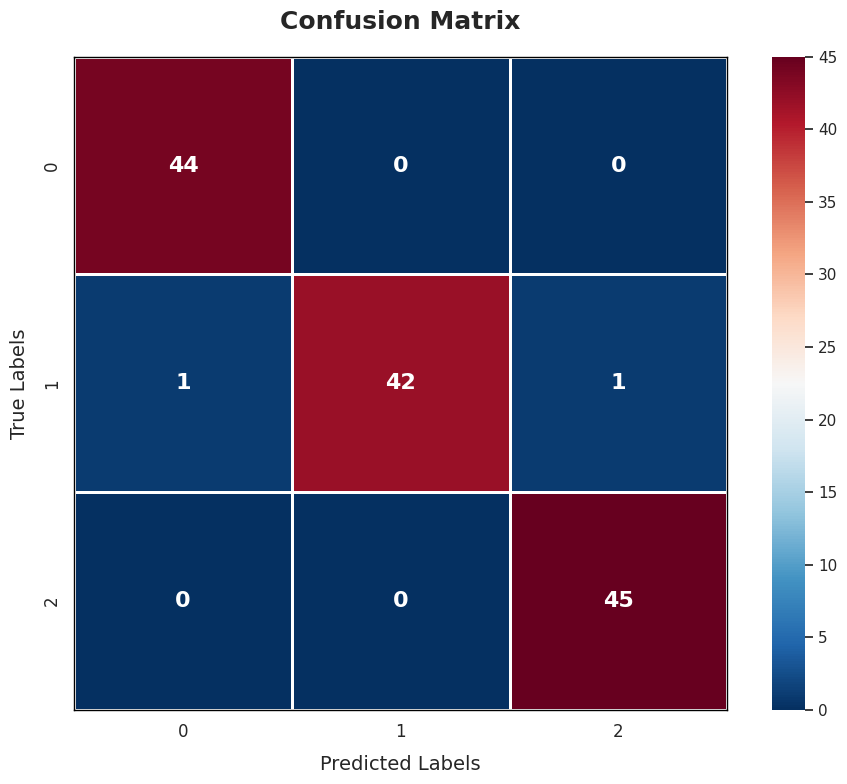

In [33]:
# Set the style
sns.set(style="white")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Create figure with custom size
plt.figure(figsize=(10, 8))

# Create the subplot
ax = plt.subplot()

# Get confusion matrix
CM = confusion_matrix(y_true, y_pred)

# Create an improved heatmap with a diverging colormap
sns.heatmap(
    CM,
    annot=True,               # Show values in cells
    fmt='g',                  # Format as integer
    ax=ax,
    cmap='RdBu_r',            # Red-Blue reversed colormap (blue for high values)
    cbar=True,                # Show colorbar for reference
    linewidths=1,             # Add cell borders
    linecolor='white',        # White cell borders
    square=True,              # Make cells square-shaped
    annot_kws={"size": 16, "weight": "bold"},  # Annotation text styling
)

# Improve labels
ax.set_xlabel('Predicted Labels', fontsize=14, labelpad=10)
ax.set_ylabel('True Labels', fontsize=14, labelpad=10)
ax.set_title('Confusion Matrix', fontsize=18, fontweight='bold', pad=20)

# Adjust ticks if needed (uncomment and modify as needed for your specific case)
# ax.set_xticklabels(['Class 0', 'Class 1', ...])
# ax.set_yticklabels(['Class 0', 'Class 1', ...])
ax.tick_params(labelsize=12)

# Add gridlines
ax.grid(False)  # Remove default grid

# Add a nice border around the plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()

In [34]:
target_names = ["healthy", "angular_leaf_spot", "bean_rust"]
clf_report = classification_report(y_true, y_pred, target_names = target_names)
print(clf_report)

                   precision    recall  f1-score   support

          healthy       0.98      1.00      0.99        44
angular_leaf_spot       1.00      0.95      0.98        44
        bean_rust       0.98      1.00      0.99        45

         accuracy                           0.98       133
        macro avg       0.99      0.98      0.98       133
     weighted avg       0.99      0.98      0.98       133



In [35]:
Acc = accuracy_score(y_true,y_pred)
print("accuracy is: {0:.3f}%".format(Acc * 100))

accuracy is: 98.496%
